# 06 — Business Insights: The Value of Product Intelligence
## TechPulse: Product Intelligence Platform

**EN:** This notebook translates all technical findings into actionable business insights. Designed for non-technical stakeholders, investors, and product managers.

**ES:** Este notebook traduce todos los hallazgos técnicos en insights accionables de negocio. Diseñado para stakeholders no técnicos, inversores y product managers.

---

### What this system does / Qué hace este sistema

**EN:** TechPulse analyzes 152,000+ digital products launched on Product Hunt over a decade to answer three business questions:
1. **What's growing?** — Which product categories will dominate in 2025–2026
2. **What's the market structure?** — How the digital product ecosystem is segmented
3. **What's relevant to you?** — Personalized product recommendations based on your interests

**ES:** TechPulse analiza más de 152,000 productos digitales lanzados en Product Hunt durante una década para responder tres preguntas de negocio:
1. **¿Qué está creciendo?** — Qué categorías de productos dominarán en 2025–2026
2. **¿Cuál es la estructura del mercado?** — Cómo está segmentado el ecosistema de productos digitales
3. **¿Qué es relevante para ti?** — Recomendaciones personalizadas basadas en tus intereses

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

ROOT      = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
MODELS    = ROOT / 'models'
FIGURES   = ROOT / 'reports' / 'figures'

PALETTE = {
    'primary'  : '#2563EB',
    'secondary': '#7C3AED',
    'accent'   : '#059669',
    'warning'  : '#D97706',
    'danger'   : '#DC2626',
    'gray'     : '#6B7280',
    'light'    : '#F9FAFB',
}
COLORS = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'],
          PALETTE['warning'], PALETTE['danger'], '#0891B2', '#BE185D',
          '#065F46', '#92400E', '#1E3A5F']

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor'  : '#E5E7EB', 'axes.labelcolor': '#374151',
    'axes.titlesize'  : 13, 'axes.labelsize': 11,
    'xtick.color'     : '#6B7280', 'ytick.color': '#6B7280',
    'grid.color'      : '#F3F4F6', 'grid.linestyle': '--',
    'font.family'     : 'sans-serif', 'text.color': '#111827',
})

print("✅ Configuración cargada")

✅ Configuración cargada


In [7]:
df           = pd.read_parquet(PROCESSED / 'clustered_products.parquet')
forecasts_df = pd.read_parquet(PROCESSED / 'forecasts.parquet')
trends_df    = pd.read_parquet(PROCESSED / 'category_trends.parquet')
profiles_df  = pd.read_parquet(PROCESSED / 'cluster_profiles.parquet')

df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['year']       = df['created_at'].dt.year.astype(int)

print("✅ Todos los outputs cargados")
print(f"   Productos          : {len(df):,}")
print(f"   Categorías forecast: {len(trends_df)}")
print(f"   Clusters           : {len(profiles_df)}")

✅ Todos los outputs cargados
   Productos          : 125,579
   Categorías forecast: 7
   Clusters           : 10


## Insight 1 — The Decade in Numbers / La Década en Números

**EN:** One decade of digital product launches, condensed into five numbers that tell the story of the tech ecosystem.

**ES:** Una década de lanzamientos de productos digitales, condensada en cinco números que cuentan la historia del ecosistema tech.

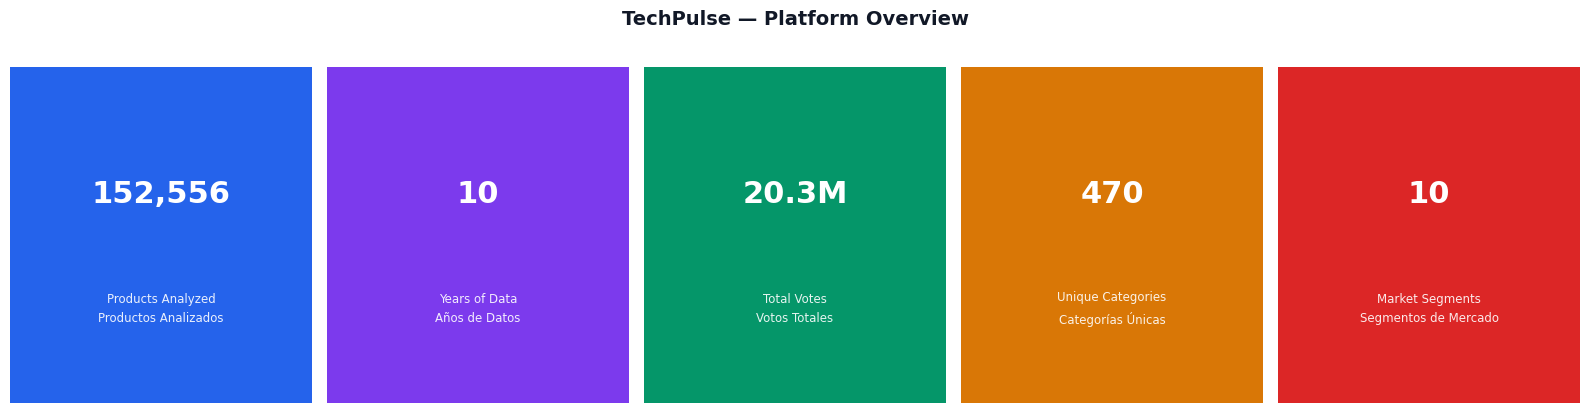

✅ Figura guardada: 14_kpi_overview.png


In [8]:
kpis = [
    ("152,556",  "Products Analyzed\nProductos Analizados",        PALETTE['primary']),
    ("10",       "Years of Data\nAños de Datos",                   PALETTE['secondary']),
    ("20.3M",    "Total Votes\nVotos Totales",                     PALETTE['accent']),
    ("470",      "Unique Categories\nCategorías Únicas",           PALETTE['warning']),
    ("10",       "Market Segments\nSegmentos de Mercado",          PALETTE['danger']),
]

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, (value, label, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center',
            fontsize=8.5, color='white', alpha=0.9, transform=ax.transAxes,
            linespacing=1.6)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('TechPulse — Platform Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '14_kpi_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 14_kpi_overview.png")

## Insight 2 — Market Opportunity Map / Mapa de Oportunidad de Mercado

**EN:** Not all categories are equal. This matrix plots each market segment by its current size and projected growth — revealing where the real opportunities are.

**ES:** No todas las categorías son iguales. Esta matriz ubica cada segmento de mercado por su tamaño actual y crecimiento proyectado — revelando dónde están las oportunidades reales.

**How to read it / Cómo leerlo:**
- **Top-right:** Large market + high growth → Star opportunities
- **Top-left:** Small market + high growth → Emerging niches  
- **Bottom-right:** Large market + low growth → Mature markets
- **Bottom-left:** Small market + low growth → Declining segments

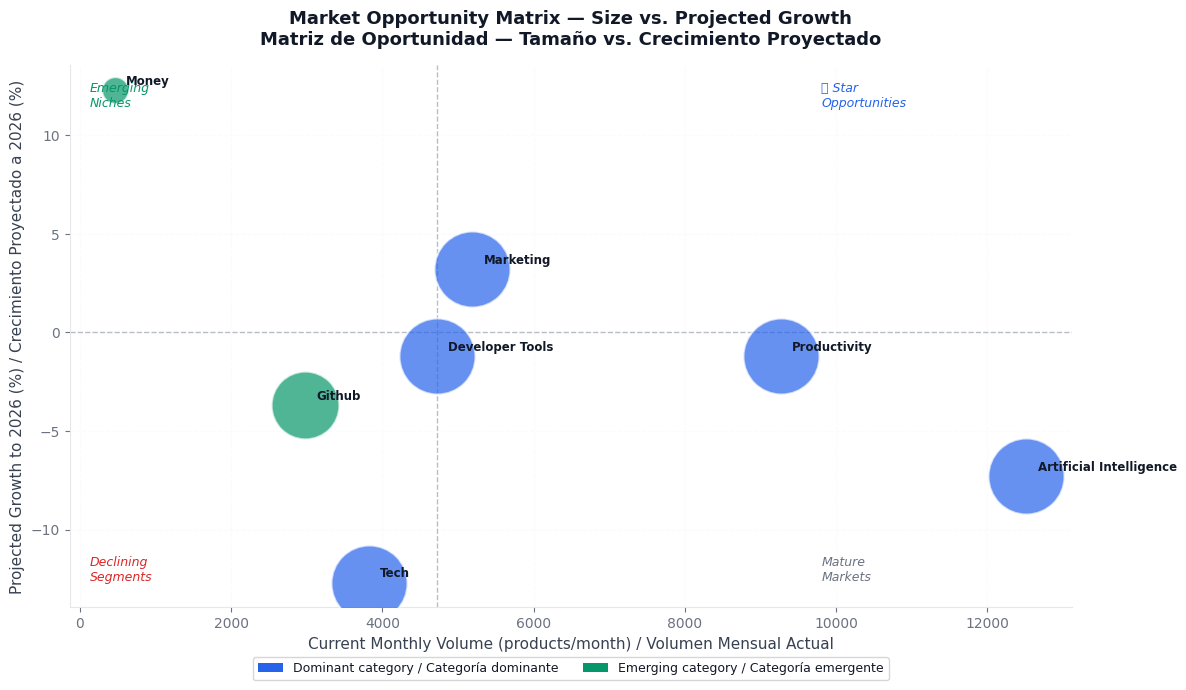

✅ Figura guardada: 15_opportunity_matrix.png


In [9]:
# Enriquecer trends con tamaño de mercado
market_size = df.groupby('topics').size().reset_index(name='total_products')

# Unir con trends
plot_df = trends_df.copy()
plot_df['market_size'] = plot_df['last_observed'] * 12  # anualizado

fig, ax = plt.subplots(figsize=(12, 7))

for i, (_, row) in enumerate(plot_df.iterrows()):
    x    = row['market_size']
    y    = row['growth_pct']
    size = max(200, min(row['market_size'] * 0.8, 3000))
    color = PALETTE['accent'] if not row['is_dominant'] else PALETTE['primary']

    ax.scatter(x, y, s=size, color=color, alpha=0.7, zorder=3, edgecolors='white', linewidth=1.5)
    ax.annotate(row['category'],
                xy=(x, y),
                xytext=(8, 4),
                textcoords='offset points',
                fontsize=8.5,
                fontweight='bold',
                color='#111827')

# Líneas de referencia
ax.axhline(0, color='#9CA3AF', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(plot_df['market_size'].median(), color='#9CA3AF',
           linewidth=1, linestyle='--', alpha=0.7)

# Etiquetas de cuadrantes
ax.text(0.02, 0.97, 'Emerging\nNiches', transform=ax.transAxes,
        fontsize=9, color=PALETTE['accent'], fontstyle='italic', va='top')
ax.text(0.75, 0.97, '⭐ Star\nOpportunities', transform=ax.transAxes,
        fontsize=9, color=PALETTE['primary'], fontstyle='italic', va='top')
ax.text(0.02, 0.05, 'Declining\nSegments', transform=ax.transAxes,
        fontsize=9, color=PALETTE['danger'], fontstyle='italic')
ax.text(0.75, 0.05, 'Mature\nMarkets', transform=ax.transAxes,
        fontsize=9, color=PALETTE['gray'], fontstyle='italic')

legend_elements = [
    mpatches.Patch(facecolor=PALETTE['primary'], label='Dominant category / Categoría dominante'),
    mpatches.Patch(facecolor=PALETTE['accent'],  label='Emerging category / Categoría emergente'),
]
ax.legend(handles=legend_elements, loc='upper center',
          bbox_to_anchor=(0.5, -0.08), ncol=2, fontsize=9)

ax.set_title('Market Opportunity Matrix — Size vs. Projected Growth\n'
             'Matriz de Oportunidad — Tamaño vs. Crecimiento Proyectado',
             fontweight='bold', pad=15)
ax.set_xlabel('Current Monthly Volume (products/month) / Volumen Mensual Actual')
ax.set_ylabel('Projected Growth to 2026 (%) / Crecimiento Proyectado a 2026 (%)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(FIGURES / '15_opportunity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 15_opportunity_matrix.png")

## Insight 3 — The Anatomy of Successful Products / La Anatomía del Producto Exitoso

**EN:** What separates a product with 10 votes from one with 10,000? We analyzed engagement patterns across all segments.

**ES:** ¿Qué separa un producto con 10 votos de uno con 10,000? Analizamos patrones de engagement en todos los segmentos.

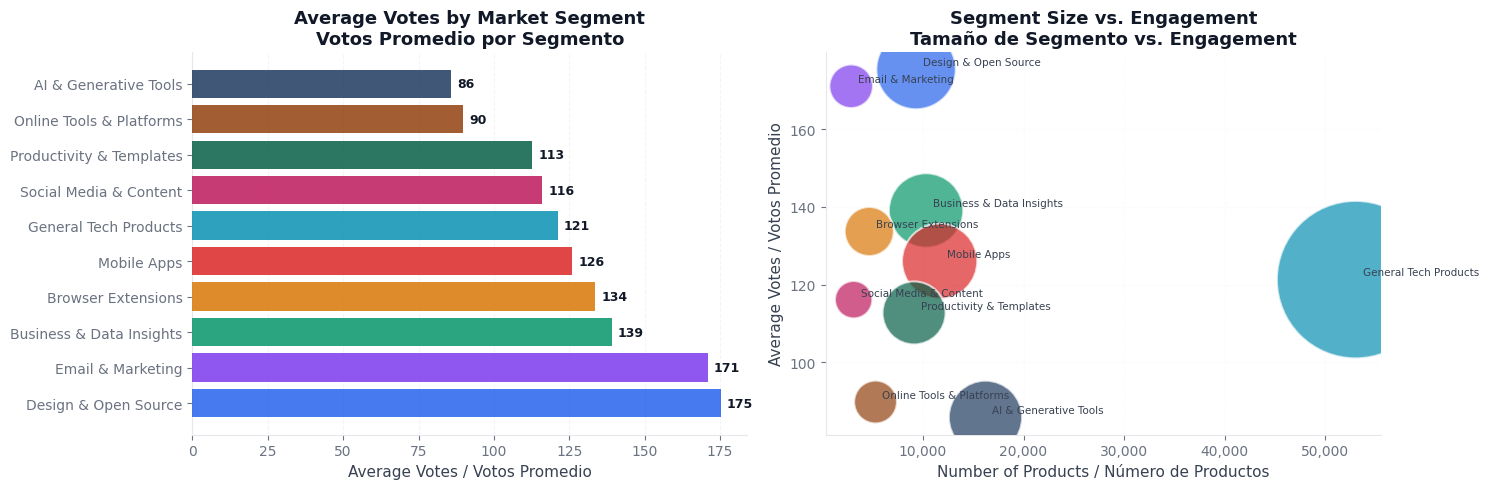

✅ Figura guardada: 16_cluster_engagement.png


In [10]:
cluster_engagement = (df.groupby('cluster_name')
                      .agg(
                          avg_votes   = ('votes', 'mean'),
                          median_votes= ('votes', 'median'),
                          n_products  = ('votes', 'count'),
                          total_votes = ('votes', 'sum')
                      )
                      .reset_index()
                      .sort_values('avg_votes', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: avg votes por cluster
colors_bar = [COLORS[i % len(COLORS)] for i in range(len(cluster_engagement))]
bars = axes[0].barh(cluster_engagement['cluster_name'],
                    cluster_engagement['avg_votes'],
                    color=colors_bar, alpha=0.85, zorder=3)

for bar, val in zip(bars, cluster_engagement['avg_votes']):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
                 f'{val:.0f}', va='center', fontsize=9, fontweight='bold')

axes[0].set_title('Average Votes by Market Segment\nVotos Promedio por Segmento',
                  fontweight='bold')
axes[0].set_xlabel('Average Votes / Votos Promedio')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='x', zorder=0)

# Gráfico 2: tamaño vs engagement (bubble)
axes[1].scatter(cluster_engagement['n_products'],
                cluster_engagement['avg_votes'],
                s=cluster_engagement['total_votes'] / 500,
                c=colors_bar, alpha=0.7, edgecolors='white', linewidth=1.5, zorder=3)

for _, row in cluster_engagement.iterrows():
    axes[1].annotate(row['cluster_name'],
                     xy=(row['n_products'], row['avg_votes']),
                     xytext=(5, 3), textcoords='offset points',
                     fontsize=7.5, color='#374151')

axes[1].set_title('Segment Size vs. Engagement\nTamaño de Segmento vs. Engagement',
                  fontweight='bold')
axes[1].set_xlabel('Number of Products / Número de Productos')
axes[1].set_ylabel('Average Votes / Votos Promedio')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig(FIGURES / '16_cluster_engagement.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 16_cluster_engagement.png")

## Insight 4 — The AI Signal / La Señal de IA

**EN:** Artificial Intelligence is not just a trend — it's the most significant structural shift in the product ecosystem in the last decade. Here's the data.

**ES:** La Inteligencia Artificial no es solo una tendencia — es el cambio estructural más significativo en el ecosistema de productos de la última década. Aquí están los datos.

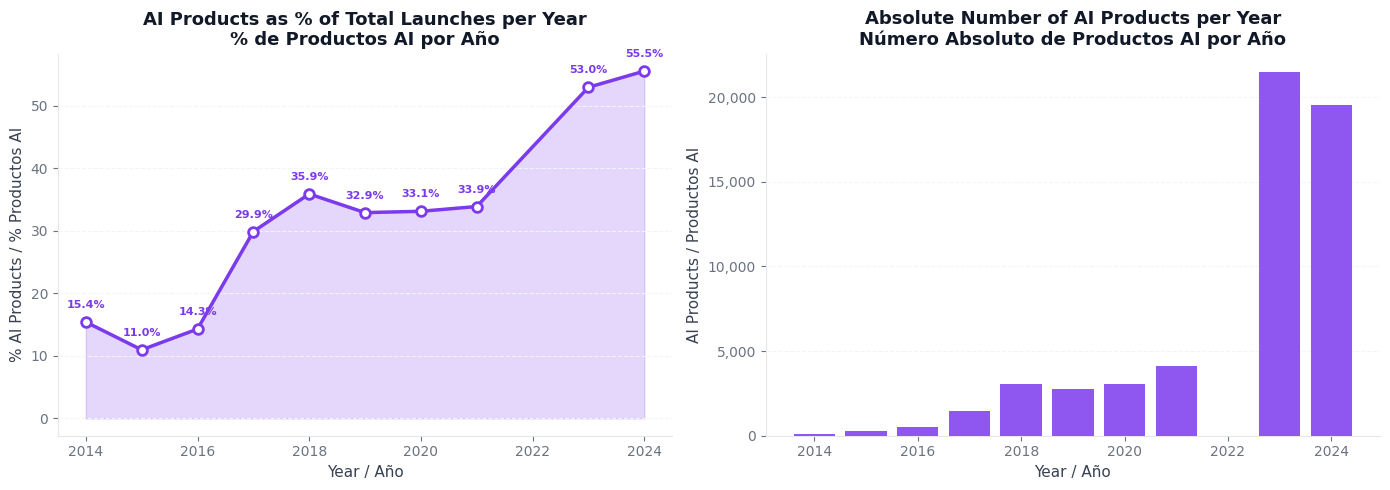

✅ Figura guardada: 17_ai_signal.png


In [11]:
# Productos con AI en topics o descripción
ai_keywords = ['artificial intelligence', 'machine learning', 'ai', 'gpt',
               'chatgpt', 'generative', 'llm', 'neural', 'deep learning']

def is_ai_product(row):
    text = ' '.join([
        str(row.get('topics', '')),
        str(row.get('description', '')),
        str(row.get('name', '')),
        str(row.get('tagline', ''))
    ]).lower()
    return any(kw in text for kw in ai_keywords)

df['is_ai'] = df.apply(is_ai_product, axis=1)

ai_by_year = df.groupby('year').agg(
    total    = ('is_ai', 'count'),
    ai_count = ('is_ai', 'sum')
).reset_index()
ai_by_year['ai_pct'] = ai_by_year['ai_count'] / ai_by_year['total'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: % de productos AI por año
axes[0].fill_between(ai_by_year['year'], ai_by_year['ai_pct'],
                     alpha=0.2, color=PALETTE['secondary'])
axes[0].plot(ai_by_year['year'], ai_by_year['ai_pct'],
             color=PALETTE['secondary'], linewidth=2.5, marker='o',
             markersize=7, markerfacecolor='white', markeredgewidth=2)

for _, row in ai_by_year.iterrows():
    axes[0].annotate(f"{row['ai_pct']:.1f}%",
                     xy=(row['year'], row['ai_pct']),
                     xytext=(0, 10), textcoords='offset points',
                     fontsize=8, ha='center', color=PALETTE['secondary'],
                     fontweight='bold')

axes[0].set_title('AI Products as % of Total Launches per Year\n'
                  '% de Productos AI por Año',
                  fontweight='bold')
axes[0].set_xlabel('Year / Año')
axes[0].set_ylabel('% AI Products / % Productos AI')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y')

# Gráfico 2: volumen absoluto
axes[1].bar(ai_by_year['year'], ai_by_year['ai_count'],
            color=PALETTE['secondary'], alpha=0.85, zorder=3)
axes[1].set_title('Absolute Number of AI Products per Year\n'
                  'Número Absoluto de Productos AI por Año',
                  fontweight='bold')
axes[1].set_xlabel('Year / Año')
axes[1].set_ylabel('AI Products / Productos AI')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig(FIGURES / '17_ai_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 17_ai_signal.png")

## Insight 5 — Business Value & Replicability / Valor de Negocio y Replicabilidad

**EN:** This system is not just a portfolio project. It's a replicable intelligence framework that any company can deploy with their own data.

**ES:** Este sistema no es solo un proyecto de portafolio. Es un framework de inteligencia replicable que cualquier empresa puede desplegar con sus propios datos.

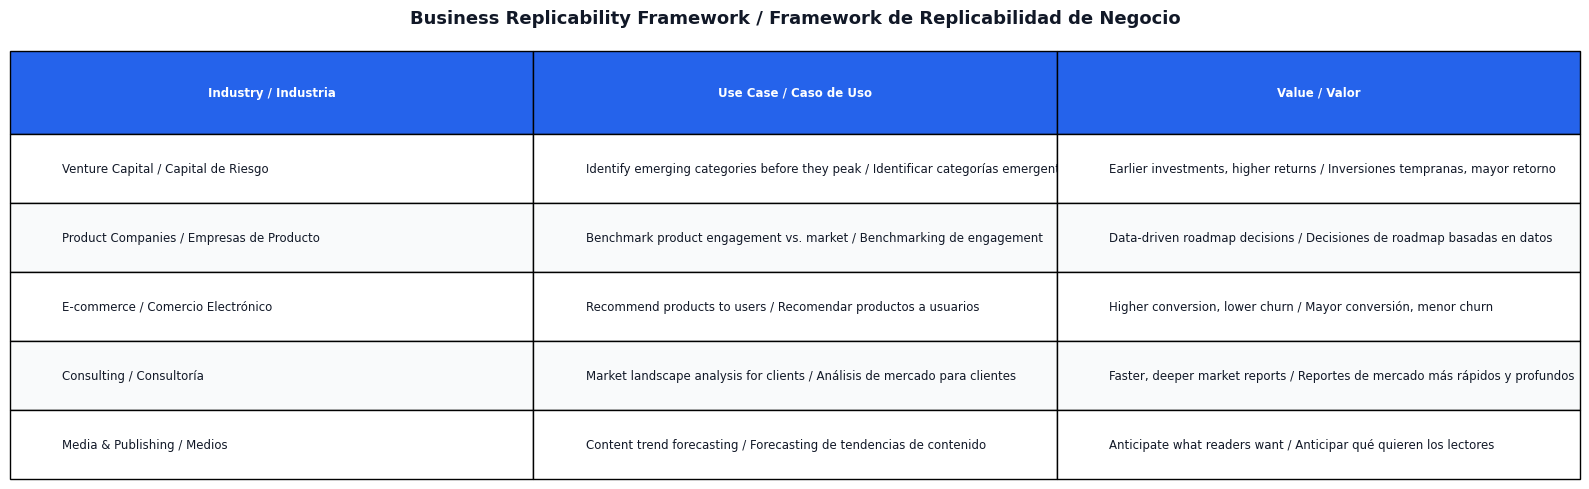

✅ Figura guardada: 18_replicability_framework.png


In [12]:
use_cases = {
    'Industry / Industria': [
        'Venture Capital / Capital de Riesgo',
        'Product Companies / Empresas de Producto',
        'E-commerce / Comercio Electrónico',
        'Consulting / Consultoría',
        'Media & Publishing / Medios',
    ],
    'Use Case / Caso de Uso': [
        'Identify emerging categories before they peak / Identificar categorías emergentes',
        'Benchmark product engagement vs. market / Benchmarking de engagement',
        'Recommend products to users / Recomendar productos a usuarios',
        'Market landscape analysis for clients / Análisis de mercado para clientes',
        'Content trend forecasting / Forecasting de tendencias de contenido',
    ],
    'Value / Valor': [
        'Earlier investments, higher returns / Inversiones tempranas, mayor retorno',
        'Data-driven roadmap decisions / Decisiones de roadmap basadas en datos',
        'Higher conversion, lower churn / Mayor conversión, menor churn',
        'Faster, deeper market reports / Reportes de mercado más rápidos y profundos',
        'Anticipate what readers want / Anticipar qué quieren los lectores',
    ]
}

use_cases_df = pd.DataFrame(use_cases)

fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('off')

table = ax.table(
    cellText=use_cases_df.values,
    colLabels=use_cases_df.columns,
    cellLoc='left',
    loc='center',
    bbox=[0, 0, 1, 1]
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)

# Estilo encabezados
for j in range(len(use_cases_df.columns)):
    table[0, j].set_facecolor(PALETTE['primary'])
    table[0, j].set_text_props(color='white', fontweight='bold')
    table[0, j].set_height(0.18)

# Estilo filas alternas
for i in range(1, len(use_cases_df) + 1):
    color = PALETTE['light'] if i % 2 == 0 else 'white'
    for j in range(len(use_cases_df.columns)):
        table[i, j].set_facecolor(color)
        table[i, j].set_height(0.15)

ax.set_title('Business Replicability Framework / Framework de Replicabilidad de Negocio',
             fontweight='bold', fontsize=13, pad=20)

plt.tight_layout()
plt.savefig(FIGURES / '18_replicability_framework.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura guardada: 18_replicability_framework.png")

In [13]:
print("=" * 70)
print("  EXECUTIVE SUMMARY / RESUMEN EJECUTIVO — TECHPULSE")
print("=" * 70)

total_ai = df['is_ai'].sum()
ai_pct_2024 = ai_by_year[ai_by_year['year'] == 2024]['ai_pct'].values[0]
top_cluster = cluster_engagement.iloc[0]['cluster_name']
top_cluster_votes = cluster_engagement.iloc[0]['avg_votes']
best_growth_cat = trends_df.loc[trends_df['growth_pct'].idxmax(), 'category']
best_growth_pct = trends_df['growth_pct'].max()

print(f"""
EN — KEY FINDINGS:
  1. SCALE      : 152,556 products analyzed across 10 years of data
  2. AI SIGNAL  : {total_ai:,} AI-related products ({ai_pct_2024:.1f}% of 2024 launches)
  3. TOP SEGMENT: '{top_cluster}' leads with {top_cluster_votes:.0f} avg votes/product
  4. GROWTH OPP : '{best_growth_cat}' shows highest projected growth (+{best_growth_pct:.1f}%)
  5. RECOMMENDER: Semantic search across 125,579 indexed products

ES — HALLAZGOS CLAVE:
  1. ESCALA      : 152,556 productos analizados en 10 años de datos
  2. SEÑAL AI    : {total_ai:,} productos relacionados con IA ({ai_pct_2024:.1f}% de lanzamientos 2024)
  3. TOP SEGMENTO: '{top_cluster}' lidera con {top_cluster_votes:.0f} votos promedio/producto
  4. OPORTUNIDAD : '{best_growth_cat}' muestra mayor crecimiento proyectado (+{best_growth_pct:.1f}%)
  5. RECOMENDADOR: Búsqueda semántica en 125,579 productos indexados
""")
print("=" * 70)
print("  → Next: 07_report.ipynb — PDF Report Generation")
print("=" * 70)

  EXECUTIVE SUMMARY / RESUMEN EJECUTIVO — TECHPULSE

EN — KEY FINDINGS:
  1. SCALE      : 152,556 products analyzed across 10 years of data
  2. AI SIGNAL  : 56,336 AI-related products (55.5% of 2024 launches)
  3. TOP SEGMENT: 'Design & Open Source' leads with 175 avg votes/product
  4. GROWTH OPP : 'Money' shows highest projected growth (+12.3%)
  5. RECOMMENDER: Semantic search across 125,579 indexed products

ES — HALLAZGOS CLAVE:
  1. ESCALA      : 152,556 productos analizados en 10 años de datos
  2. SEÑAL AI    : 56,336 productos relacionados con IA (55.5% de lanzamientos 2024)
  3. TOP SEGMENTO: 'Design & Open Source' lidera con 175 votos promedio/producto
  4. OPORTUNIDAD : 'Money' muestra mayor crecimiento proyectado (+12.3%)
  5. RECOMENDADOR: Búsqueda semántica en 125,579 productos indexados

  → Next: 07_report.ipynb — PDF Report Generation


## ✅ Notebook completo

**Figuras generadas:**
- `14_kpi_overview.png`
- `15_opportunity_matrix.png`
- `16_cluster_engagement.png`
- `17_ai_signal.png`
- `18_replicability_framework.png`

**Siguiente paso:** `07_report.ipynb` — Generación del informe PDF final